# CustomerIQ — Day 4
## Retention Driver Analysis

### 1. Objective

This notebook compares customer-level characteristics measured before the 2011-09-10 cutoff for customers who later returned during the 90-day validation period and customers with no observed return during that period. The comparison is descriptive only: `observed_churn` means no observed return in the validation window, not permanent churn.

### 2. Load Customer-Level Dataset

### 3. Data Verification

### 4. Outcome Distribution

### 5. Create Customer Groups

### 6. Frequency Analysis

### 7. Monetary Analysis

### 8. Recency Analysis

### 9. Customer Lifespan Analysis

### 10. Purchase Interval Analysis

### 11. Returned vs No-Return Comparison Summary

### 12. Key Retention Insights

### 13. Modeling Preparation Notes

No predictive model is trained in Day 4.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

input_path = Path("../Data/Processed/customer_churn_analysis.csv")
customers = pd.read_csv(input_path, parse_dates=["First Purchase Date", "Last Purchase Date"])

print(f"Dataset shape: {customers.shape}")
print("Columns:", list(customers.columns))
print("\nData types:")
print(customers.dtypes)
print("\nMissing values:")
print(customers.isna().sum())

Dataset shape: (3705, 11)
Columns: ['Customer ID', 'Frequency', 'Monetary', 'First Purchase Date', 'Last Purchase Date', 'Customer Lifespan', 'Recency', 'Average Purchase Interval', 'Median Purchase Interval', 'returned_in_validation', 'observed_churn']

Data types:
Customer ID                         float64
Frequency                             int64
Monetary                            float64
First Purchase Date          datetime64[us]
Last Purchase Date           datetime64[us]
Customer Lifespan                     int64
Recency                               int64
Average Purchase Interval           float64
Median Purchase Interval            float64
returned_in_validation                int64
observed_churn                        int64
dtype: object

Missing values:
Customer ID                  0
Frequency                    0
Monetary                     0
First Purchase Date          0
Last Purchase Date           0
Customer Lifespan            0
Recency                      0
A

Duplicate Customer IDs: 0
Returned distribution:
returned_in_validation
0    1732
1    1973
Name: count, dtype: int64
Observed churn distribution:
observed_churn
0    1973
1    1732
Name: count, dtype: int64

Infinite values: 0
Negative values by comparison feature:
Frequency                    0
Monetary                     0
Recency                      0
Customer Lifespan            0
Average Purchase Interval    0
Median Purchase Interval     0
dtype: int64

Validation checks passed.
Group sizes:
Returned              1973
No observed return    1732
dtype: int64

Frequency
                        Count  Mean  Median   Std  Minimum   Q1    Q3  Maximum
returned_in_validation                                                        
No observed return       1732  4.55    3.00  5.44        2 2.00  5.00      155
Returned                 1973 10.59    6.00 16.83        2 3.00 12.00      309

Monetary
                        Count     Mean   Median       Std  Minimum     Q1  \
returned_in_v

Returned                                             \
                             Count     Mean   Median       Std Minimum     Q1   
Frequency                     1973    10.59     6.00     16.83    2.00   3.00   
Monetary                      1973 5,282.32 2,078.54 19,344.31   24.05 888.79   
Recency                       1973   102.82    58.00    112.67    0.00  19.00   
Customer Lifespan             1973   372.12   395.00    194.14    0.00 210.00   
Average Purchase Interval     1973    74.07    57.40     63.88    0.00  33.40   
Median Purchase Interval      1973    66.74    47.00     66.12    0.00  24.00   

                                              No observed return           \
                                Q3    Maximum              Count     Mean   
Frequency                    12.00     309.00               1732     4.55   
Monetary                  4,499.73 456,780.49               1732 1,716.01   
Recency                     145.00     638.00               1732   215.44   
Customer Lifespan           545.00     646.00               1732   259.55   
Average Purchase Interval    92.50     538.00               1732   106.86   
Median Purchase Interval     83.00     538.00               1732    99.99   

                                                                             
                          Median      Std Minimum     Q1       Q3   Maximum  
Frequency                   3.00     5.44    2.00   2.00     5.00    155.00  
Monetary                  895.62 3,957.78   24.35 500.83 1,694.52 77,556.46  
Recency                   197.00   153.26    0.00  78.00   325.00    647.00  
Customer Lifespan         241.00   176.47    0.00 105.00   399.00    645.00  
Average Purchase Interval  82.50    94.83    0.00  43.00   140.54    632.00  
Median Purchase Interval   69.00    97.96    0.00  33.00   135.00    632.00

Skewness and kurtosis:


,Frequency,Monetary,Recency,Customer Lifespan,Average Purchase Interval,Median Purchase Interval
skew,9.95,20.18,0.91,-0.01,2.15,2.14
kurt,154.15,529.58,-0.07,-1.24,6.24,5.88


IQR-based outlier diagnostic (reported, not removed):


,Skewness,IQR outlier count,IQR lower bound,IQR upper bound
Feature,,,,
Frequency,9.95,373,-4.50,15.50
Monetary,20.18,367,"-2,884.65","6,525.88"
Recency,0.91,0,-334.00,650.00
Customer Lifespan,-0.01,0,-371.50,"1,008.50"
Average Purchase Interval,2.15,234,-80.29,232.71
Median Purchase Interval,2.14,252,-93.00,227.00


,Mean difference,Median difference
Frequency,6.03,3.00
Monetary,"3,566.31","1,182.92"
Recency,-112.62,-139.00
Customer Lifespan,112.56,154.00
Average Purchase Interval,-32.79,-25.10
Median Purchase Interval,-33.25,-22.00


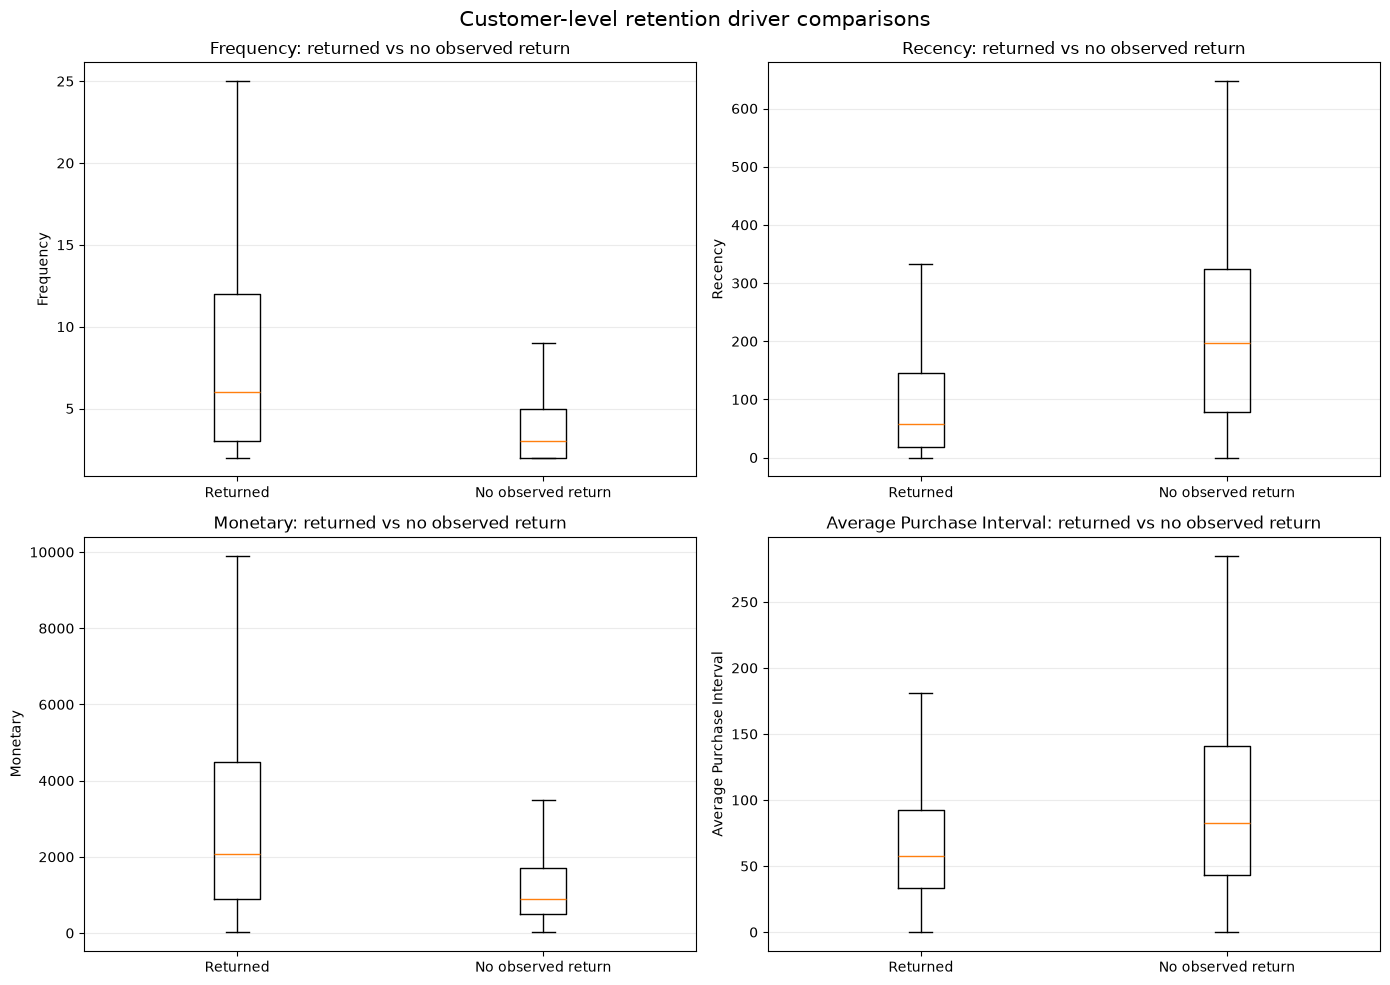

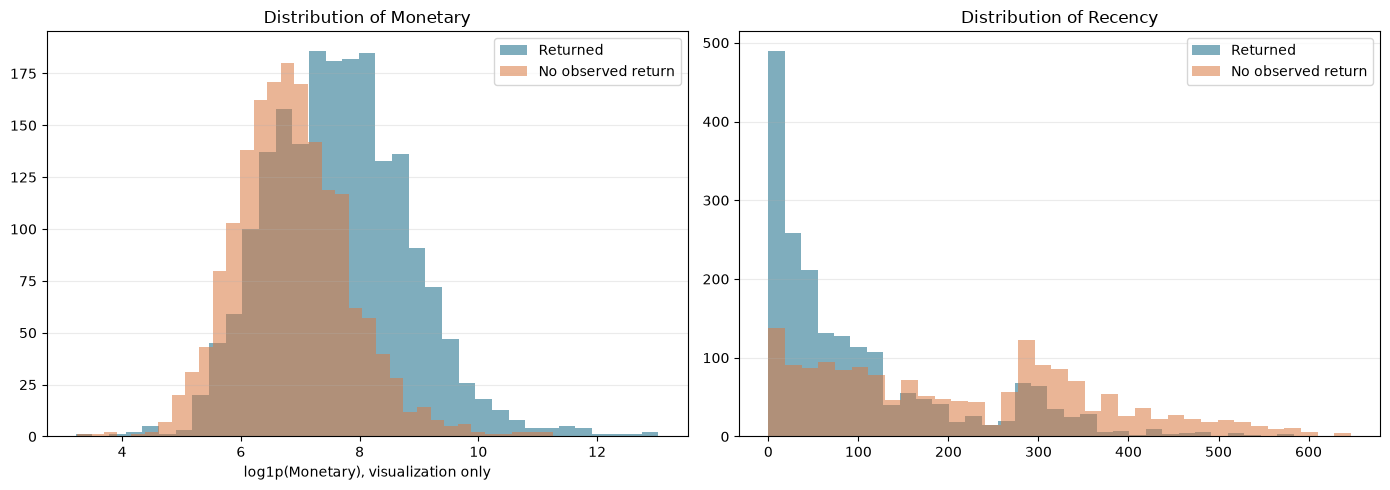

,Feature,Returned Mean,Returned Median,No Return Mean,No Return Median,Difference,Business Interpretation
0,Frequency,10.59,6.00,4.55,3.00,3.00,Returned customers had a higher median frequen...
1,Monetary,"5,282.32","2,078.54","1,716.01",895.62,"1,182.92",Returned customers had a higher median monetar...
2,Recency,102.82,58.00,215.44,197.00,-139.00,Returned customers had a lower median recency ...
3,Customer Lifespan,372.12,395.00,259.55,241.00,154.00,Returned customers had a higher median custome...
4,Average Purchase Interval,74.07,57.40,106.86,82.50,-25.10,Returned customers had a lower median average ...
5,Median Purchase Interval,66.74,47.00,99.99,69.00,-22.00,Returned customers had a lower median median p...


Strongest descriptive differences by absolute median difference:


,Absolute median difference
Monetary,"1,182.92"
Customer Lifespan,154.00
Recency,139.00
Average Purchase Interval,25.10
Median Purchase Interval,22.00
Frequency,3.00



Data-driven observations:
- Returned customers had a higher median frequency than customers with no observed return.
- Returned customers had a higher median monetary than customers with no observed return.
- Returned customers had a lower median recency than customers with no observed return.
- Returned customers had a higher median customer lifespan than customers with no observed return.
- Returned customers had a lower median average purchase interval than customers with no observed return.
- Returned customers had a lower median median purchase interval than customers with no observed return.

Modeling preparation notes:
- Candidate features for Day 5: Frequency, Monetary, Recency, Customer Lifespan, Average Purchase Interval, Median Purchase Interval
- Feature risks: Monetary and interval variables are skewed and contain IQR-defined outliers; inspect transformations during modeling without changing this analytical dataset.
- Leakage risk: retain only features calculated before t

In [3]:
comparison_features = [
    "Frequency",
    "Monetary",
    "Recency",
    "Customer Lifespan",
    "Average Purchase Interval",
    "Median Purchase Interval",
]

print("Duplicate Customer IDs:", customers["Customer ID"].duplicated().sum())
print("Returned distribution:")
print(customers["returned_in_validation"].value_counts().sort_index())
print("Observed churn distribution:")
print(customers["observed_churn"].value_counts().sort_index())

numeric_check = customers[comparison_features + ["returned_in_validation", "observed_churn"]]
print("\nInfinite values:", np.isinf(numeric_check.to_numpy()).sum())
print("Negative values by comparison feature:")
print((customers[comparison_features] < 0).sum())

assert len(customers) == 3705
assert customers["Customer ID"].is_unique
assert set(customers["returned_in_validation"].unique()) == {0, 1}
assert customers[comparison_features].apply(pd.api.types.is_numeric_dtype).all()
assert not np.isinf(numeric_check.to_numpy()).any()
assert not customers[comparison_features].isna().any().any()

print("\nValidation checks passed.")

groups = {
    "Returned": customers.loc[customers["returned_in_validation"] == 1].copy(),
    "No observed return": customers.loc[customers["returned_in_validation"] == 0].copy(),
}

print("Group sizes:")
print(pd.Series({name: len(group) for name, group in groups.items()}))

stats = {}
for feature in comparison_features:
    feature_stats = customers.groupby("returned_in_validation")[feature].agg(
        Count="count",
        Mean="mean",
        Median="median",
        Std="std",
        Minimum="min",
        Q1=lambda series: series.quantile(0.25),
        Q3=lambda series: series.quantile(0.75),
        Maximum="max",
    )
    stats[feature] = feature_stats.rename(index={1: "Returned", 0: "No observed return"})

    print(f"\n{feature}")
    print(stats[feature])

summary_stats = pd.DataFrame(
    {
        (group_name, statistic): [stats[feature].loc[group_name, statistic] for feature in comparison_features]
        for group_name in ["Returned", "No observed return"]
        for statistic in ["Count", "Mean", "Median", "Std", "Minimum", "Q1", "Q3", "Maximum"]
    },
    index=comparison_features,
)

display(summary_stats)

skewness = customers[comparison_features].agg(["skew", "kurt"])
outlier_rows = []
for feature in comparison_features:
    q1 = customers[feature].quantile(0.25)
    q3 = customers[feature].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_rows.append(
        {
            "Feature": feature,
            "Skewness": customers[feature].skew(),
            "IQR outlier count": ((customers[feature] < lower) | (customers[feature] > upper)).sum(),
            "IQR lower bound": lower,
            "IQR upper bound": upper,
        }
    )
outlier_summary = pd.DataFrame(outlier_rows).set_index("Feature")
print("Skewness and kurtosis:")
display(skewness)
print("IQR-based outlier diagnostic (reported, not removed):")
display(outlier_summary)

mean_difference = summary_stats[("Returned", "Mean")] - summary_stats[("No observed return", "Mean")]
median_difference = summary_stats[("Returned", "Median")] - summary_stats[("No observed return", "Median")]
comparison_differences = pd.DataFrame({"Mean difference": mean_difference, "Median difference": median_difference})
display(comparison_differences)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plot_features = ["Frequency", "Recency", "Monetary", "Average Purchase Interval"]
for axis, feature in zip(axes.flat, plot_features):
    axis.boxplot(
        [groups["Returned"][feature], groups["No observed return"][feature]],
        tick_labels=["Returned", "No observed return"],
        showfliers=False,
    )
    axis.set_title(f"{feature}: returned vs no observed return")
    axis.set_ylabel(feature)
    axis.grid(axis="y", alpha=0.25)
fig.suptitle("Customer-level retention driver comparisons", fontsize=15)
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for axis, feature in zip(axes, ["Monetary", "Recency"]):
    for group_name, color in [("Returned", "#176b87"), ("No observed return", "#d97941")]:
        values = groups[group_name][feature]
        if feature == "Monetary":
            values = np.log1p(values)
            axis.set_xlabel("log1p(Monetary), visualization only")
        axis.hist(values, bins=35, alpha=0.55, label=group_name, color=color)
    axis.set_title(f"Distribution of {feature}")
    axis.legend()
    axis.grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.show()

summary_table = pd.DataFrame(
    {
        "Feature": comparison_features,
        "Returned Mean": [stats[feature].loc["Returned", "Mean"] for feature in comparison_features],
        "Returned Median": [stats[feature].loc["Returned", "Median"] for feature in comparison_features],
        "No Return Mean": [stats[feature].loc["No observed return", "Mean"] for feature in comparison_features],
        "No Return Median": [stats[feature].loc["No observed return", "Median"] for feature in comparison_features],
        "Difference": [median_difference[feature] for feature in comparison_features],
    }
)

def interpretation(row):
    direction = "higher" if row["Difference"] > 0 else "lower" if row["Difference"] < 0 else "the same"
    return f"Returned customers had a {direction} median {row['Feature'].lower()} than customers with no observed return."

summary_table["Business Interpretation"] = summary_table.apply(interpretation, axis=1)
display(summary_table)

median_abs_differences = comparison_differences["Median difference"].abs().sort_values(ascending=False)
print("Strongest descriptive differences by absolute median difference:")
display(median_abs_differences.to_frame("Absolute median difference"))
print("\nData-driven observations:")
for _, row in summary_table.iterrows():
    print("-", row["Business Interpretation"])
print("\nModeling preparation notes:")
print("- Candidate features for Day 5:", ", ".join(comparison_features))
print("- Feature risks: Monetary and interval variables are skewed and contain IQR-defined outliers; inspect transformations during modeling without changing this analytical dataset.")
print("- Leakage risk: retain only features calculated before the cutoff; returned_in_validation and observed_churn are outcomes and must not be predictors.")
print("- Potential overlap: Customer Lifespan, Recency, and purchase intervals all encode temporal purchasing history and may be correlated; quantify correlation during Day 5.")
print("- Recommended next step: use these descriptive results to define a leakage-safe modeling workflow, then validate it on held-out data.")
print("\nNo predictive model was trained during Day 4.")